# 74 - AI-Generated Summary Contamination: Per-Query and Per-Scaling-Tier Numbers

Backs the concrete numbers used in the Introduction, Chapter 2, and Chapter 4 (Section~\ref{sec:trust_filter}) about AI-generated company summaries describing a website hosting/platform provider instead of the company's own business.

Two analyses:

1. **Per-query contamination in the original 98,716-company corpus.** Reuses the already-computed `result/summary_quality/summary_quality_query_contamination.csv` (from `trust_feature.compute_query_contamination()`), the exact source of the 85.4% / 73.1% / 53.1% figures already cited in the thesis for "web hosting companies", "cloud computing providers", and "e-commerce platforms". This section just loads it, sanity-checks it, and plots all 101 queries so the concentration pattern (a handful of infrastructure-adjacent queries badly affected, almost everything else clean) is visible at a glance rather than three numbers in prose.

2. **Contamination at each scaling-corpus tier (100K / 200K / 300K / ~397K).** Not previously computed. Reuses the exact same boilerplate classifier (296 reference templates, cosine-similarity threshold 0.97, `MIN_WORDS`/junk-phrase checks) from `trust_feature.py`, but against the nested scaling pool built in notebook 44, and reuses the already-encoded MiniLM embeddings from notebook 45 instead of re-embedding 397,025 summaries from scratch.

**Note on normalisation.** The scaling-corpus MiniLM embeddings were encoded for exact `IndexFlatL2` search (Section~\ref{subsec:minilm} notes MiniLM does not require normalisation for that use), while `trust_feature.py`'s reference templates are always encoded with `normalize_embeddings=True`. Cosine similarity requires both sides normalised, so this notebook explicitly re-normalises both the company and template embeddings before the similarity computation, rather than assuming the cached `.npy` file is already unit-norm.

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUTPUT_DIR = Path("result/74_ai_summary_contamination_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## Part 1: Per-query contamination (original 98,716-company corpus)

In [2]:
per_query = pd.read_csv("result/summary_quality/summary_quality_query_contamination.csv")
per_query = per_query.sort_values("pct_junk", ascending=False).reset_index(drop=True)

print(f"queries: {len(per_query)}")
print(f"queries with any contamination: {(per_query['pct_junk'] > 0).sum()}")
print(f"mean pct_junk across all queries: {per_query['pct_junk'].mean():.1f}%")
print(f"median pct_junk across all queries: {per_query['pct_junk'].median():.1f}%")
per_query.head(10)

queries: 101
queries with any contamination: 57
mean pct_junk across all queries: 4.0%
median pct_junk across all queries: 0.6%


,query,n_relevant_total,n_relevant_junk,pct_junk
0,web hosting companies,1000,854,85.4
1,cloud computing providers,1000,731,73.1
2,e-commerce platforms,1000,531,53.1
3,content management systems (CMS),1000,332,33.2
4,internet service providers,1000,182,18.2
5,web design agencies,1000,117,11.7
6,waste management companies,1000,92,9.2
7,pharmaceutical companies,1000,72,7.2
8,data center providers,403,28,6.9
9,aerospace companies,233,15,6.4


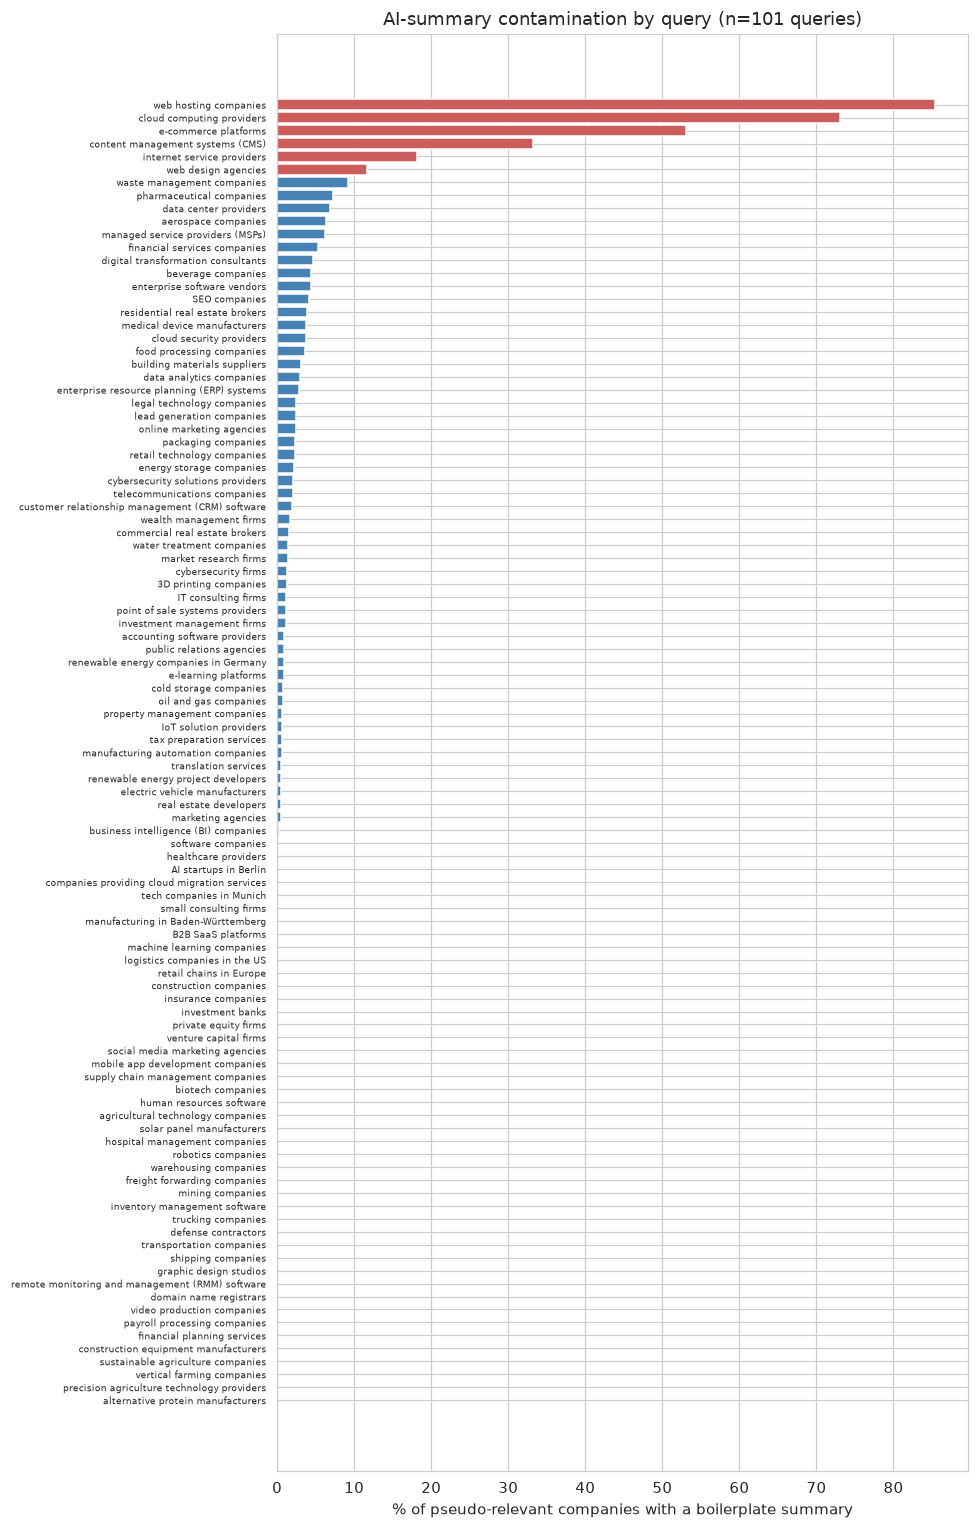

In [3]:
fig, ax = plt.subplots(figsize=(9, 14))
colors = ["indianred" if v >= 10 else "steelblue" for v in per_query["pct_junk"]]
ax.barh(per_query["query"], per_query["pct_junk"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("% of pseudo-relevant companies with a boilerplate summary")
ax.set_title("AI-summary contamination by query (n=101 queries)")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_query_contamination.png")
plt.show()

57 of 101 queries have any measurable contamination


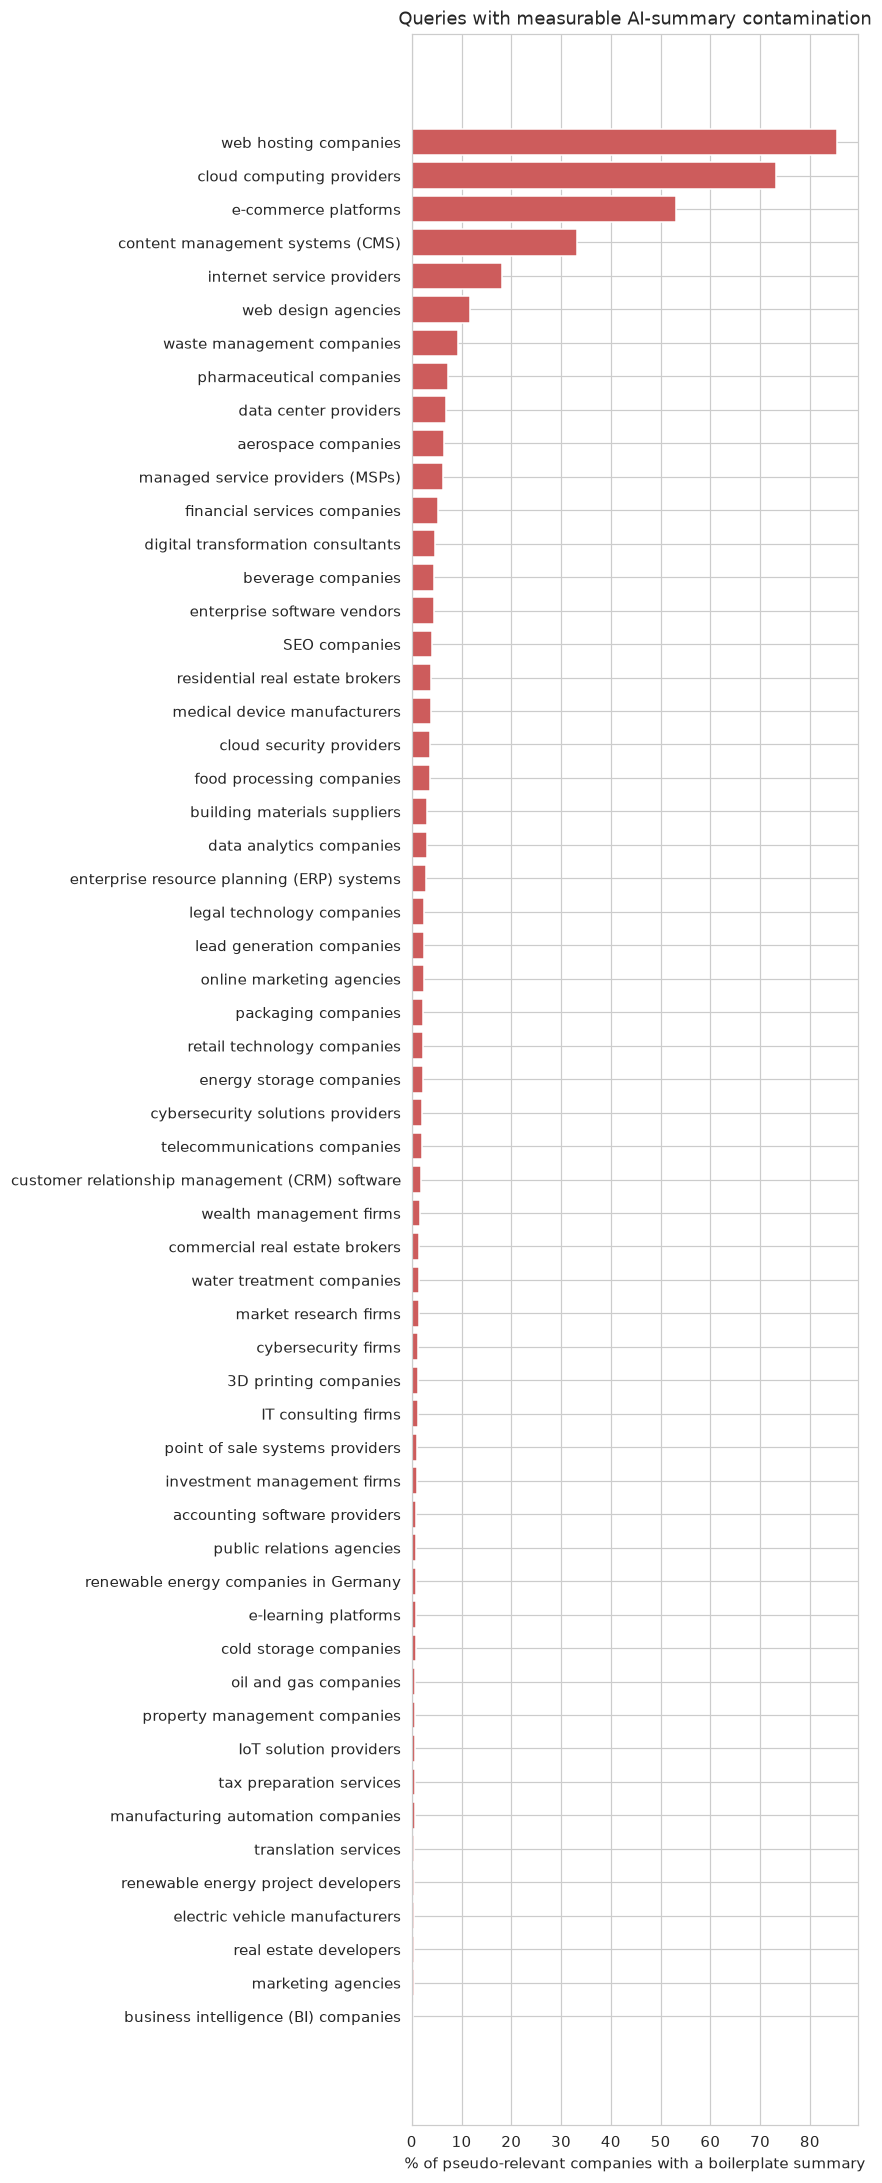

In [4]:
# Zoomed view: only the queries with any measurable contamination, full labels readable
affected = per_query[per_query["pct_junk"] > 0]
print(f"{len(affected)} of {len(per_query)} queries have any measurable contamination")

fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(affected))))
ax.barh(affected["query"], affected["pct_junk"], color="indianred")
ax.invert_yaxis()
ax.set_xlabel("% of pseudo-relevant companies with a boilerplate summary")
ax.set_title("Queries with measurable AI-summary contamination")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_query_contamination_affected_only.png")
plt.show()

## Part 2: Contamination at each scaling-corpus tier (100K / 200K / 300K / ~397K)

In [5]:
pool = pd.read_parquet(
    "result/44_build_scaled_corpus/combined_pool.parquet",
    columns=["domain", "summary", "source", "in_100k", "in_200k", "in_300k", "in_400k"],
)
print(f"combined pool rows: {len(pool)}")
pool[["source", "in_100k", "in_200k", "in_300k", "in_400k"]].groupby("source").sum()

combined pool rows: 397025


,in_100k,in_200k,in_300k,in_400k
source,,,,
existing,98716,98716,98716,98716
new,1284,101284,201284,298309


In [6]:
company_embeddings = np.load("result/45_encode_minilm_scaled/company_embeddings.npy", mmap_mode="r")
assert company_embeddings.shape[0] == len(pool), "embedding row count must match pool row count"

template_data = np.load("result/trust_filter/boilerplate_template_embeddings.npz", allow_pickle=True)
template_embeddings = template_data["embeddings"].astype(np.float32)
print(f"company embeddings: {company_embeddings.shape}, template embeddings: {template_embeddings.shape}")

company embeddings: (397025, 384), template embeddings: (296, 384)


In [7]:
MIN_WORDS = 15
SUMMARY_JUNK_PHRASES = [
    "web hosting", "website hosting", "hosting provider", "shared hosting", "vps hosting",
    "reseller hosting", "domain registrar", "domain registration", "register your domain",
    "register a domain", "buy this domain", "this domain is for sale", "domain name is for sale",
    "domain is available", "parked domain", "parked page", "website builder", "site builder",
    "under construction", "coming soon", "default page", "this website is for sale",
    "godaddy", "namecheap", "bluehost", "hostgator", "wordpress.com", "wix.com", "squarespace",
]
SUMMARY_JUNK_RE = re.compile("|".join(re.escape(p) for p in SUMMARY_JUNK_PHRASES), re.IGNORECASE)
BOILERPLATE_THRESHOLD = 0.97  # same threshold used throughout the thesis (best F1 from trust_feature.py's own validation sweep)

def l2_normalize(x, axis=1):
    norms = np.linalg.norm(x, axis=axis, keepdims=True)
    norms[norms == 0] = 1.0
    return x / norms

In [8]:
# Chunked similarity computation: avoids materializing the full company embedding
# array in memory at once, even though 397,025 x 384 floats comfortably fits.
CHUNK = 50_000
max_sims = np.empty(len(pool), dtype=np.float32)
template_embeddings_norm = l2_normalize(template_embeddings)

for start in range(0, len(pool), CHUNK):
    end = min(start + CHUNK, len(pool))
    chunk = np.asarray(company_embeddings[start:end], dtype=np.float32)
    chunk_norm = l2_normalize(chunk)
    sims = chunk_norm @ template_embeddings_norm.T
    max_sims[start:end] = sims.max(axis=1)
    print(f"{end}/{len(pool)} companies scored...")

pool["boilerplate_similarity"] = max_sims

50000/397025 companies scored...
100000/397025 companies scored...
150000/397025 companies scored...
200000/397025 companies scored...
250000/397025 companies scored...
300000/397025 companies scored...
350000/397025 companies scored...
397025/397025 companies scored...


In [9]:
word_counts = pool["summary"].fillna("").apply(lambda s: len(str(s).split()))
junk_phrase_hit = pool["summary"].fillna("").apply(lambda s: bool(SUMMARY_JUNK_RE.search(str(s))))

pool["contaminated"] = (
    (word_counts < MIN_WORDS)
    | junk_phrase_hit
    | (pool["boilerplate_similarity"] >= BOILERPLATE_THRESHOLD)
)

print(f"contaminated overall (full ~397K pool): {pool['contaminated'].mean() * 100:.1f}%")
pool.groupby("source")["contaminated"].mean().mul(100).round(1)

contaminated overall (full ~397K pool): 1.0%


source
existing    2.8
new         0.4
Name: contaminated, dtype: float64

In [10]:
tier_cols = {"100K": "in_100k", "200K": "in_200k", "300K": "in_300k", "397K": "in_400k"}

rows = []
for tier_label, col in tier_cols.items():
    subset = pool[pool[col]]
    for source_label in ["existing", "new"]:
        source_subset = subset[subset["source"] == source_label]
        if len(source_subset) == 0:
            continue
        rows.append({
            "tier": tier_label,
            "source": source_label,
            "n_companies": len(source_subset),
            "pct_contaminated": round(100 * source_subset["contaminated"].mean(), 2),
        })
    rows.append({
        "tier": tier_label,
        "source": "all",
        "n_companies": len(subset),
        "pct_contaminated": round(100 * subset["contaminated"].mean(), 2),
    })

tier_df = pd.DataFrame(rows)
tier_df.to_csv(OUTPUT_DIR / "tier_contamination.csv", index=False)
tier_df

,tier,source,n_companies,pct_contaminated
0,100K,existing,98716,2.84
1,100K,new,1284,0.39
2,100K,all,100000,2.81
3,200K,existing,98716,2.84
4,200K,new,101284,0.41
5,200K,all,200000,1.61
6,300K,existing,98716,2.84
7,300K,new,201284,0.41
8,300K,all,300000,1.21
9,397K,existing,98716,2.84


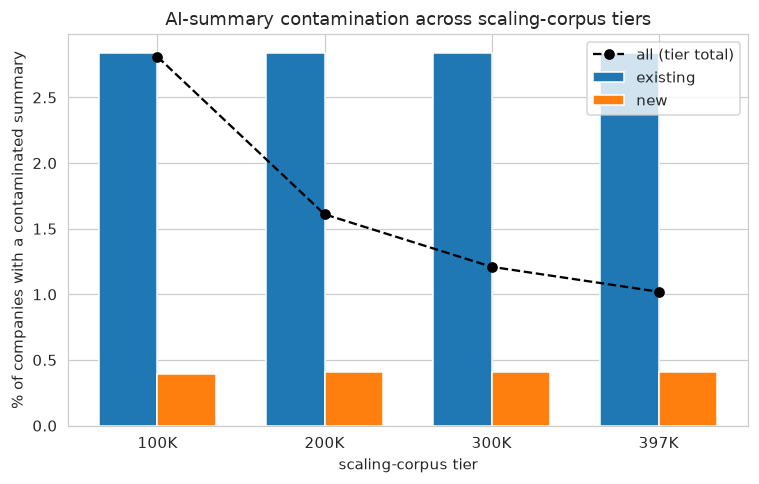

In [11]:
tier_order = ["100K", "200K", "300K", "397K"]
plot_df = tier_df[tier_df["source"].isin(["existing", "new"])].copy()
plot_df["tier"] = pd.Categorical(plot_df["tier"], categories=tier_order, ordered=True)
plot_df = plot_df.sort_values("tier")

fig, ax = plt.subplots(figsize=(7, 4.5))
width = 0.35
x = np.arange(len(tier_order))
for i, source_label in enumerate(["existing", "new"]):
    sub = plot_df[plot_df["source"] == source_label].set_index("tier").reindex(tier_order)
    ax.bar(x + (i - 0.5) * width, sub["pct_contaminated"], width, label=source_label)

all_df = tier_df[tier_df["source"] == "all"].set_index("tier").reindex(tier_order)
ax.plot(x, all_df["pct_contaminated"], marker="o", color="black", linestyle="--", label="all (tier total)")

ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_xlabel("scaling-corpus tier")
ax.set_ylabel("% of companies with a contaminated summary")
ax.set_title("AI-summary contamination across scaling-corpus tiers")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tier_contamination.png")
plt.show()

## Summary for the thesis

In [12]:
summary = {
    "per_query": {
        "n_queries": int(len(per_query)),
        "n_queries_any_contamination": int((per_query["pct_junk"] > 0).sum()),
        "mean_pct_junk": float(per_query["pct_junk"].mean()),
        "median_pct_junk": float(per_query["pct_junk"].median()),
        "top_5_worst": per_query.head(5)[["query", "pct_junk"]].to_dict(orient="records"),
    },
    "by_tier": tier_df.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'per_query': {'n_queries': 101,
  'n_queries_any_contamination': 57,
  'mean_pct_junk': 3.9594059405940594,
  'median_pct_junk': 0.6,
  'top_5_worst': [{'query': 'web hosting companies', 'pct_junk': 85.4},
   {'query': 'cloud computing providers', 'pct_junk': 73.1},
   {'query': 'e-commerce platforms', 'pct_junk': 53.1},
   {'query': 'content management systems (CMS)', 'pct_junk': 33.2},
   {'query': 'internet service providers', 'pct_junk': 18.2}]},
 'by_tier': [{'tier': '100K',
   'source': 'existing',
   'n_companies': 98716,
   'pct_contaminated': 2.84},
  {'tier': '100K',
   'source': 'new',
   'n_companies': 1284,
   'pct_contaminated': 0.39},
  {'tier': '100K',
   'source': 'all',
   'n_companies': 100000,
   'pct_contaminated': 2.81},
  {'tier': '200K',
   'source': 'existing',
   'n_companies': 98716,
   'pct_contaminated': 2.84},
  {'tier': '200K',
   'source': 'new',
   'n_companies': 101284,
   'pct_contaminated': 0.41},
  {'tier': '200K',
   'source': 'all',
   'n_compani

### Notes for writing this up

- The per-query plot makes the concentration pattern visible directly: contamination is not spread across the corpus, it clusters in a small number of infrastructure-adjacent query topics (web hosting, cloud computing, e-commerce platforms, CMS, ISPs), exactly the mechanism already described in Section~\ref{sec:trust_filter}.
- The tier-level analysis answers a question the thesis doesn't currently address: does contamination get better or worse as the corpus scales toward the full GOI? If the `new` (randomly sampled) companies show a similar or lower contamination rate than `existing`, that's a reassuring sign the issue doesn't compound at scale; if `new` is notably worse, that's worth a sentence in the Limitations discussion in Section~\ref{subsec:honest_synthesis} or the scaling section itself.
- This tier-level contamination check uses the same classifier and threshold as the rest of the thesis (F1=0.59 against the LLM-judged validation sample, Section~\ref{sec:trust_filter_result}), so it inherits the same known precision/recall limitations, it is a consistent, not a more accurate, measurement than the original corpus's numbers.
- If any of these tier-level numbers get cited in the thesis, cite this notebook and `result/74_ai_summary_contamination_analysis/tier_contamination.csv` as the source, the same way other result folders are cited elsewhere.